# Brownian motion

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import scienceplots
plt.style.use('science')
import numpy as np
from numpy.random import rand
import matplotlib as mpl
np.seed = 123
import math

## Symmetric random walk

Let $S$ be a symmetric random walk, that is

$$
P(S_{n+1} = s + 1 / S_n = s) = p
$$

$$
P(S_{n+1} = s - 1 / S_n = s) = 1 - p = q
$$

In [2]:
# x is the starting point and he walker advance with a probability of prob
def next_step(x, prob):
    if (rand() < prob):
        return x + 1
    else:
        return x - 1

In [3]:
# k is the starting point of the random walker
def random_walk(N, k = 0, prob = 0.5):
    steps = np.zeros(N, dtype = np.int64)
    steps[0] = k
    for i in range(1, N):
        steps[i] = next_step(steps[i-1], prob)
    return steps

In [4]:
n = 1000
s = random_walk(n)

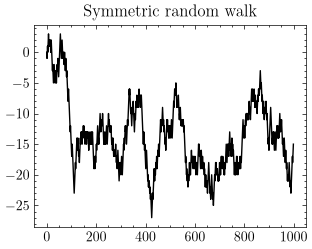

In [5]:
plt.plot(s, color = "black")
plt.title("Symmetric random walk")
plt.show()

## Continuous random walk

In [6]:
def continuous_random_walk(x, T, n):
    # t in [0, T] with increment deltat
    deltat = T / n
    trange = np.arange(0, T, deltat)
    y = np.zeros(n)
    i = 0
    for t in trange:
        y[i] = math.sqrt(deltat) * x[math.floor(t / deltat)]
        i += 1
    return np.array(y)

In [7]:
ns = [1000, 750, 500, 250]
xs = [continuous_random_walk(s, s.size, n) for n in ns]
deltats = [s.size / n for n in ns]

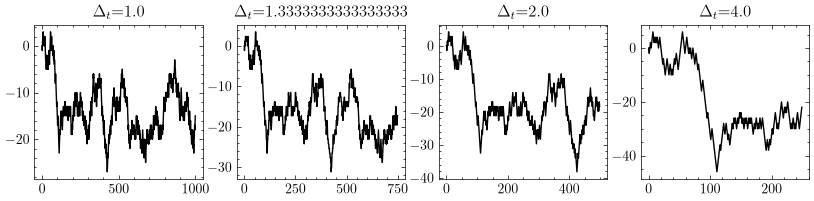

In [8]:
fig, axes = plt.subplots(1, 4, figsize = (10, 2))
for i in range(4):
    axes[i].plot(xs[i], color = "black")
    axes[i].set_title(r"$\Delta_t$=" + str(deltats[i]))
plt.show()

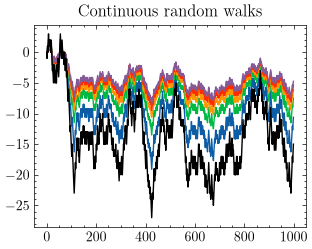

In [9]:
for k in range(2, 11, 2):
    plt.plot(continuous_random_walk(s, s.size // k, s.size))
plt.plot(s, color = "black")
plt.title("Continuous random walks")
plt.show()

## Different $\Delta_t$

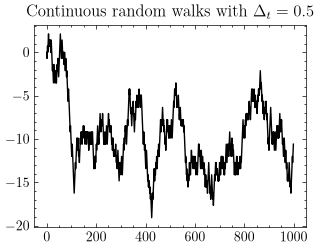

In [10]:
plt.plot(continuous_random_walk(s, s.size / 2, 1000), color = "black")
plt.title(r"Continuous random walks with $\Delta_t = 0.5$")
plt.show()

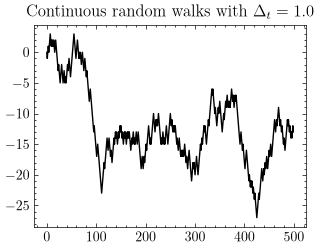

In [11]:
plt.plot(continuous_random_walk(s, s.size / 2, 500), color = "black")
plt.title(r"Continuous random walks with $\Delta_t = 1.0$")
plt.show()

## Brownian motion / Donker's invariance principle

In [12]:
def brownian_motion(s, T):
    deltat = 1. / T
    s = s.cumsum()
    n = s.size
    w = np.zeros(T)
    t = 0.
    i = 0
    while math.floor(n*t) < n:
        w[i] = s[math.floor(n*t)] * math.sqrt(deltat) / math.sqrt(n)
        t += deltat
        i += 1
    return w

In [13]:
w = brownian_motion(s, n)

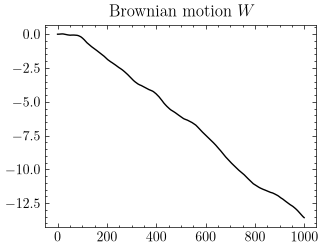

In [14]:
plt.plot(w, color = "black")
plt.title(r"Brownian motion $W$")
plt.show()

## Brownian motion paths

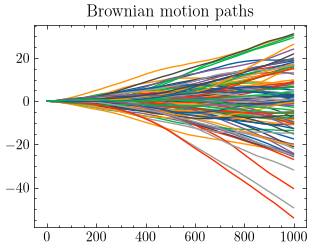

In [15]:
for i in range(100):
    sr = random_walk(n)
    wr = brownian_motion(sr, n)
    plt.plot(wr)
plt.title("Brownian motion paths")
plt.show()

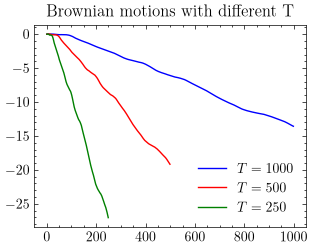

In [16]:
plt.plot(brownian_motion(s, 1000), label =r"$T=1000$", color = "blue")
plt.plot(brownian_motion(s, 500), label = r"$T=500$", color = "red")
plt.plot(brownian_motion(s, 250), label = r"$T=250$", color = "green")
plt.legend()
plt.title("Brownian motions with different T")
plt.show()

In [17]:
def diff(w):
    diffw = np.zeros(w.size - 1)
    for i in range(diffw.size):
        diffw[i] = w[i+1] - w[i]
    return diffw

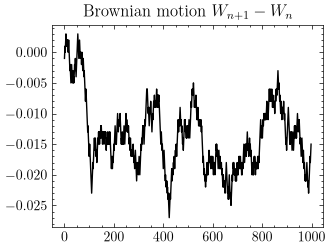

In [18]:
# Check that the difference is in [-1, 1]
diffw = diff(w)
plt.plot(diffw, color = "black")
plt.title("Brownian motion $W_{n+1}-W_{n}$")
plt.show()

## Paths and limit

In [19]:
# Save paths into W[n,t]
n = 1000
T = 500
W = np.zeros((n, T))
for i in range(n):
    S = random_walk(n)
    W[i, :] = brownian_motion(S, T)

## Central limit theorem

**Expectation and variance**

In [20]:
E = np.zeros(T)
V = np.zeros(T)
for i in range(T):
    E[i] = W[:, i].mean()
    V[i] = W[:, i].var()

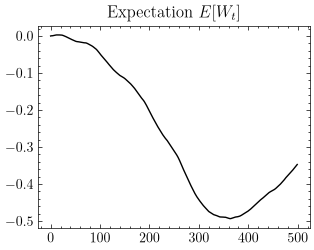

In [21]:
plt.plot(E, color = "black")
plt.title(r"Expectation $E[W_t]$")
plt.show()

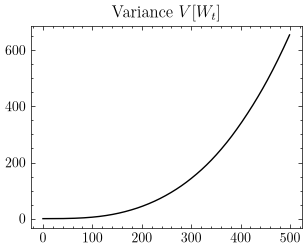

In [22]:
plt.plot(V, color = "black")
plt.title(r"Variance $V[W_t]$")
plt.show()

**Paths**

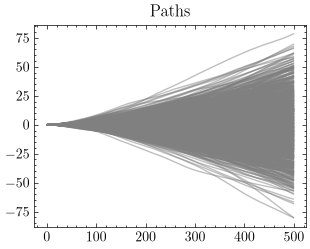

In [23]:
for i in range(n):
    plt.plot(W[i, :], color = "grey", alpha = .5)
plt.title("Paths")
plt.show()

**Density / Histograms when $T -> +\infty$**

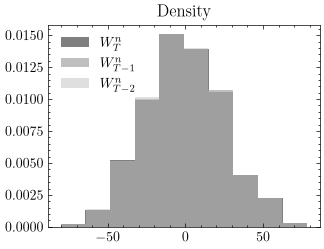

In [24]:
plt.hist(W[:, T-1], density = True, color = "black", alpha = .5, label = r"$W^{n}_{T}$")
plt.hist(W[:, T-2], density = True, color = "grey", alpha = .5, label = r"$W^{n}_{T-1}$")
plt.hist(W[:, T-3], density = True, color = "silver", alpha = .5, label = r"$W^{n}_{T-2}$")
plt.title("Density")
plt.legend()
plt.show()